# Cross-Lingual Embedding Visualization (NMTTrans)

Visualizing semantic alignment and attention behavior from the trained **NMTTrans** model.

This notebook loads the 60M checkpoint **once** and reuses that shared model for the plots below, so the visualizations stay consistent and the setup runs faster.

| Feature | Detail |
|---|---|
| Model | Shared `NMTTrans` instance from `final_60m_model.pt` |
| Dimensionality reduction | t-SNE (2-D) |
| English words | Blue circles |
| Telugu words | Red squares |
| Translation-pair lines | Colored by cosine sim |
| Neighbor links | Dotted gray → top-3 nearest Telugu neighbors per English word |
| Clustering | Agglomerative clusters shown as shaded convex hulls |

In [1]:
# ---- Telugu font configuration for matplotlib ----
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Register the Lohit Telugu font so matplotlib can render Telugu script
_telugu_font_path = '/usr/share/fonts/lohit-telugu/Lohit-Telugu.ttf'
fm.fontManager.addfont(_telugu_font_path)
_telugu_font_prop = fm.FontProperties(fname=_telugu_font_path)
_telugu_font_name = _telugu_font_prop.get_name()
print(f'Telugu font registered: {_telugu_font_name}')

# Set the Telugu font as a fallback by prepending it to the font family list
# This allows matplotlib to find Telugu glyphs while keeping default fonts for Latin text
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = [_telugu_font_name] + matplotlib.rcParams.get('font.sans-serif', ['DejaVu Sans'])
# Rebuild the font cache
# matplotlib.font_manager._rebuild()
print('Matplotlib font configuration updated for Telugu support.')
# ---- End Telugu font configuration ----

import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import sentencepiece as spm

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Shared setup for all visualizations
DEVICE = torch.device('cpu')
ROOT = Path('..')
CACHE_DIR = ROOT / 'cache'
CKPT_DIR = CACHE_DIR / 'checkpoints'
TOKENIZER_PATH = CACHE_DIR / 'nmt_unigram_v1_32000.model'

VOCAB_SIZE = 32000
MAX_SEQ_LEN = 128
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

MODEL_CONFIGS = {
    '10M': {'d_model': 256, 'nhead': 4, 'num_enc_layers': 3, 'num_dec_layers': 3, 'd_ff': 1024, 'dropout': 0.10},
    '30M': {'d_model': 512, 'nhead': 8, 'num_enc_layers': 4, 'num_dec_layers': 4, 'd_ff': 2048, 'dropout': 0.10},
    '50M': {'d_model': 512, 'nhead': 8, 'num_enc_layers': 6, 'num_dec_layers': 6, 'd_ff': 2304, 'dropout': 0.10},
    '60M': {'d_model': 640, 'nhead': 8, 'num_enc_layers': 6, 'num_dec_layers': 6, 'd_ff': 2560, 'dropout': 0.12},
}

sp = spm.SentencePieceProcessor(model_file=str(TOKENIZER_PATH))
print(f'Tokenizer loaded: {TOKENIZER_PATH.name} | vocab={sp.get_piece_size()}')


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, : x.size(1)])


class EncoderStack(nn.Module):
    def __init__(self, d_model: int, nhead: int, d_ff: int, num_layers: int, dropout: float):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, src_key_padding_mask: torch.Tensor) -> torch.Tensor:
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)


class DecoderStack(nn.Module):
    def __init__(self, d_model: int, nhead: int, d_ff: int, num_layers: int, dropout: float):
        super().__init__()
        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)

    def forward(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor,
        tgt_key_padding_mask: torch.Tensor,
        memory_key_padding_mask: torch.Tensor,
    ) -> torch.Tensor:
        return self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )


class NMTTrans(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        nhead: int,
        num_enc_layers: int,
        num_dec_layers: int,
        d_ff: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.scale = math.sqrt(d_model)

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.position = PositionalEncoding(d_model=d_model, max_len=MAX_SEQ_LEN, dropout=dropout)
        self.encoder = EncoderStack(d_model=d_model, nhead=nhead, d_ff=d_ff, num_layers=num_enc_layers, dropout=dropout)
        self.decoder = DecoderStack(d_model=d_model, nhead=nhead, d_ff=d_ff, num_layers=num_dec_layers, dropout=dropout)

        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight
        self._init_weights()

    def _init_weights(self) -> None:
        for parameter in self.parameters():
            if parameter.dim() > 1:
                nn.init.xavier_uniform_(parameter)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_pad_mask = src.eq(PAD_ID)
        tgt_pad_mask = tgt.eq(PAD_ID)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        src_emb = self.position(self.embedding(src) * self.scale)
        tgt_emb = self.position(self.embedding(tgt) * self.scale)

        memory = self.encoder(src_emb, src_key_padding_mask=src_pad_mask)
        decoded = self.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.lm_head(decoded)


def load_checkpoint(path: Path):
    print(f'  Loading checkpoint: {path}')
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def normalize_state_dict_keys(state_dict):
    normalized = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')
        new_key = new_key.replace('pos_enc.', 'position.')
        new_key = new_key.replace('output_proj.', 'lm_head.')
        normalized[new_key] = value
    return normalized


def load_nmttrans_model(model_name: str = '60M'):
    checkpoint_path = CKPT_DIR / f'final_{model_name.lower()}_model.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

    checkpoint = load_checkpoint(checkpoint_path)
    config = checkpoint.get('config', MODEL_CONFIGS[model_name]) if isinstance(checkpoint, dict) else MODEL_CONFIGS[model_name]
    model = NMTTrans(vocab_size=VOCAB_SIZE, **config).to(DEVICE)

    weights = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
    weights = normalize_state_dict_keys(weights)

    missing_keys, unexpected_keys = model.load_state_dict(weights, strict=False)
    if missing_keys:
        print(f'  Warning: Missing {len(missing_keys)} tensors (default init used).')
    if unexpected_keys:
        print(f'  Warning: Ignoring {len(unexpected_keys)} unexpected tensors.')

    model.eval()
    print(f'Model {model_name} loaded once and ready for reuse.')
    return model


shared_model_60m = load_nmttrans_model('60M')
emb_weights_60m = shared_model_60m.embedding.weight.detach().cpu().numpy()
emb_weights = emb_weights_60m
print(f'Embedding matrix shape: {emb_weights_60m.shape}')

Telugu font registered: Lohit Telugu
Matplotlib font configuration updated for Telugu support.


Tokenizer loaded: nmt_unigram_v1_32000.model | vocab=32000
  Loading checkpoint: ../cache/checkpoints/final_60m_model.pt


/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model 60M loaded once and ready for reuse.
Embedding matrix shape: (32000, 640)


In [2]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

PAD, UNK, BOS, EOS = 0, 1, 2, 3

word_pairs = [
    ("water", "నీరు"),
    ("sun", "సూర్యుడు"),
    ("moon", "చంద్రుడు"),
    ("fire", "మంట"),
    ("earth", "భూమి"),
    ("man", "మనిషి"),
    ("woman", "మహిళ"),
    ("book", "పుస్తకం"),
    ("tree", "చెట్టు"),
    ("sky", "ఆకాశం"),
    ("light", "కాంతి"),
    ("house", "ఇల్లు"),
    ("money", "డబ్బు"),
    ("time", "సమయం"),
    ("day", "రోజు"),
    ("night", "రాత్రి"),
    ("friend", "స్నేహితుడు"),
    ("animal", "జంతువు"),
    ("bird", "పక్షి"),
    ("fish", "చేప"),
    ("king", "రాజు"),
    ("queen", "రాణి"),
    ("child", "పిల్లవాడు"),
    ("mother", "తల్లి"),
    ("father", "తండ్రి"),
    ("love", "ప్రేమ"),
    ("angry", "కోపం"),
]

def embed_word(w):
    ids = [i for i in sp.encode_as_ids(w) if i not in (PAD,UNK,BOS,EOS)]
    return emb_weights[ids].mean(0) if ids else None

eng_words, tel_words, eng_raw, tel_raw = [], [], [], []
for en, te in word_pairs:
    ev, tv = embed_word(en), embed_word(te)
    if ev is not None and tv is not None:
        eng_words.append(en); tel_words.append(te)
        eng_raw.append(ev); tel_raw.append(tv)

eng_emb = normalize(np.stack(eng_raw))
tel_emb = normalize(np.stack(tel_raw))
sim_matrix = cosine_similarity(eng_emb, tel_emb)
pair_sims = np.diag(sim_matrix)
print(f'{len(eng_words)} pairs loaded')
for w, s in zip(eng_words, pair_sims):
    tag = '🟢' if s>=0.7 else ('🟠' if s>=0.4 else '🔴')
    print(f'  {tag} {w:>8s}  {s:.3f}')

27 pairs loaded
  🔴    water  0.254
  🔴      sun  0.258
  🔴     moon  0.274
  🔴     fire  0.234
  🔴    earth  0.202
  🔴      man  0.260
  🔴    woman  0.262
  🔴     book  0.245
  🔴     tree  0.249
  🔴      sky  0.179
  🔴    light  0.248
  🔴    house  0.208
  🔴    money  0.215
  🔴     time  0.259
  🔴      day  0.236
  🔴    night  0.304
  🔴   friend  0.206
  🔴   animal  0.215
  🔴     bird  0.234
  🔴     fish  0.250
  🔴     king  0.244
  🔴    queen  0.211
  🔴    child  0.216
  🔴   mother  0.298
  🔴   father  0.227
  🔴     love  0.243
  🔴    angry  0.219


## t-SNE Projection

All embeddings (English + Telugu) are projected jointly so that
semantically similar words from **both** languages cluster together.

In [3]:
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

all_emb = np.vstack([eng_emb, tel_emb])
n = len(eng_words)

tsne = TSNE(n_components=2, perplexity=min(7, n-1), learning_rate=200, random_state=42)
proj = tsne.fit_transform(all_emb)
eng_xy, tel_xy = proj[:n], proj[n:]

n_clusters = min(6, n//2)
labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(all_emb)
print(f't-SNE done · {n_clusters} clusters')

t-SNE done · 6 clusters


## Semantic Alignment Plot

- **Solid lines** connect true translation pairs (color = cosine similarity)
- **Dotted gray lines** show each English word's top-3 nearest Telugu neighbors
- **Shaded regions** are agglomerative clusters

/tmp/ipykernel_3268563/1173209803.py:63: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  ax.axis('off'); fig.tight_layout()
/tmp/ipykernel_3268563/1173209803.py:63: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Lohit Telugu.
  ax.axis('off'); fig.tight_layout()
/tmp/ipykernel_3268563/1173209803.py:63: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Lohit Telugu.
  ax.axis('off'); fig.tight_layout()
/tmp/ipykernel_3268563/1173209803.py:64: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  plt.savefig('tsne_alignment.png',dpi=150,bbox_inches='tight')
/tmp/ipykernel_3268563/1173209803.py:64: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Lohit Telugu.
  plt.savefig('tsne_alignment.png',dpi=150,bbox_inches='tight')
/tmp/ipykernel_3268563/1173209803.py:64: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Lohit Telugu.
  plt.savefig('tsne

/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Lohit Telugu.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Lohit Telugu.
  fig.canvas.print_figure(bytes_io, **kw)


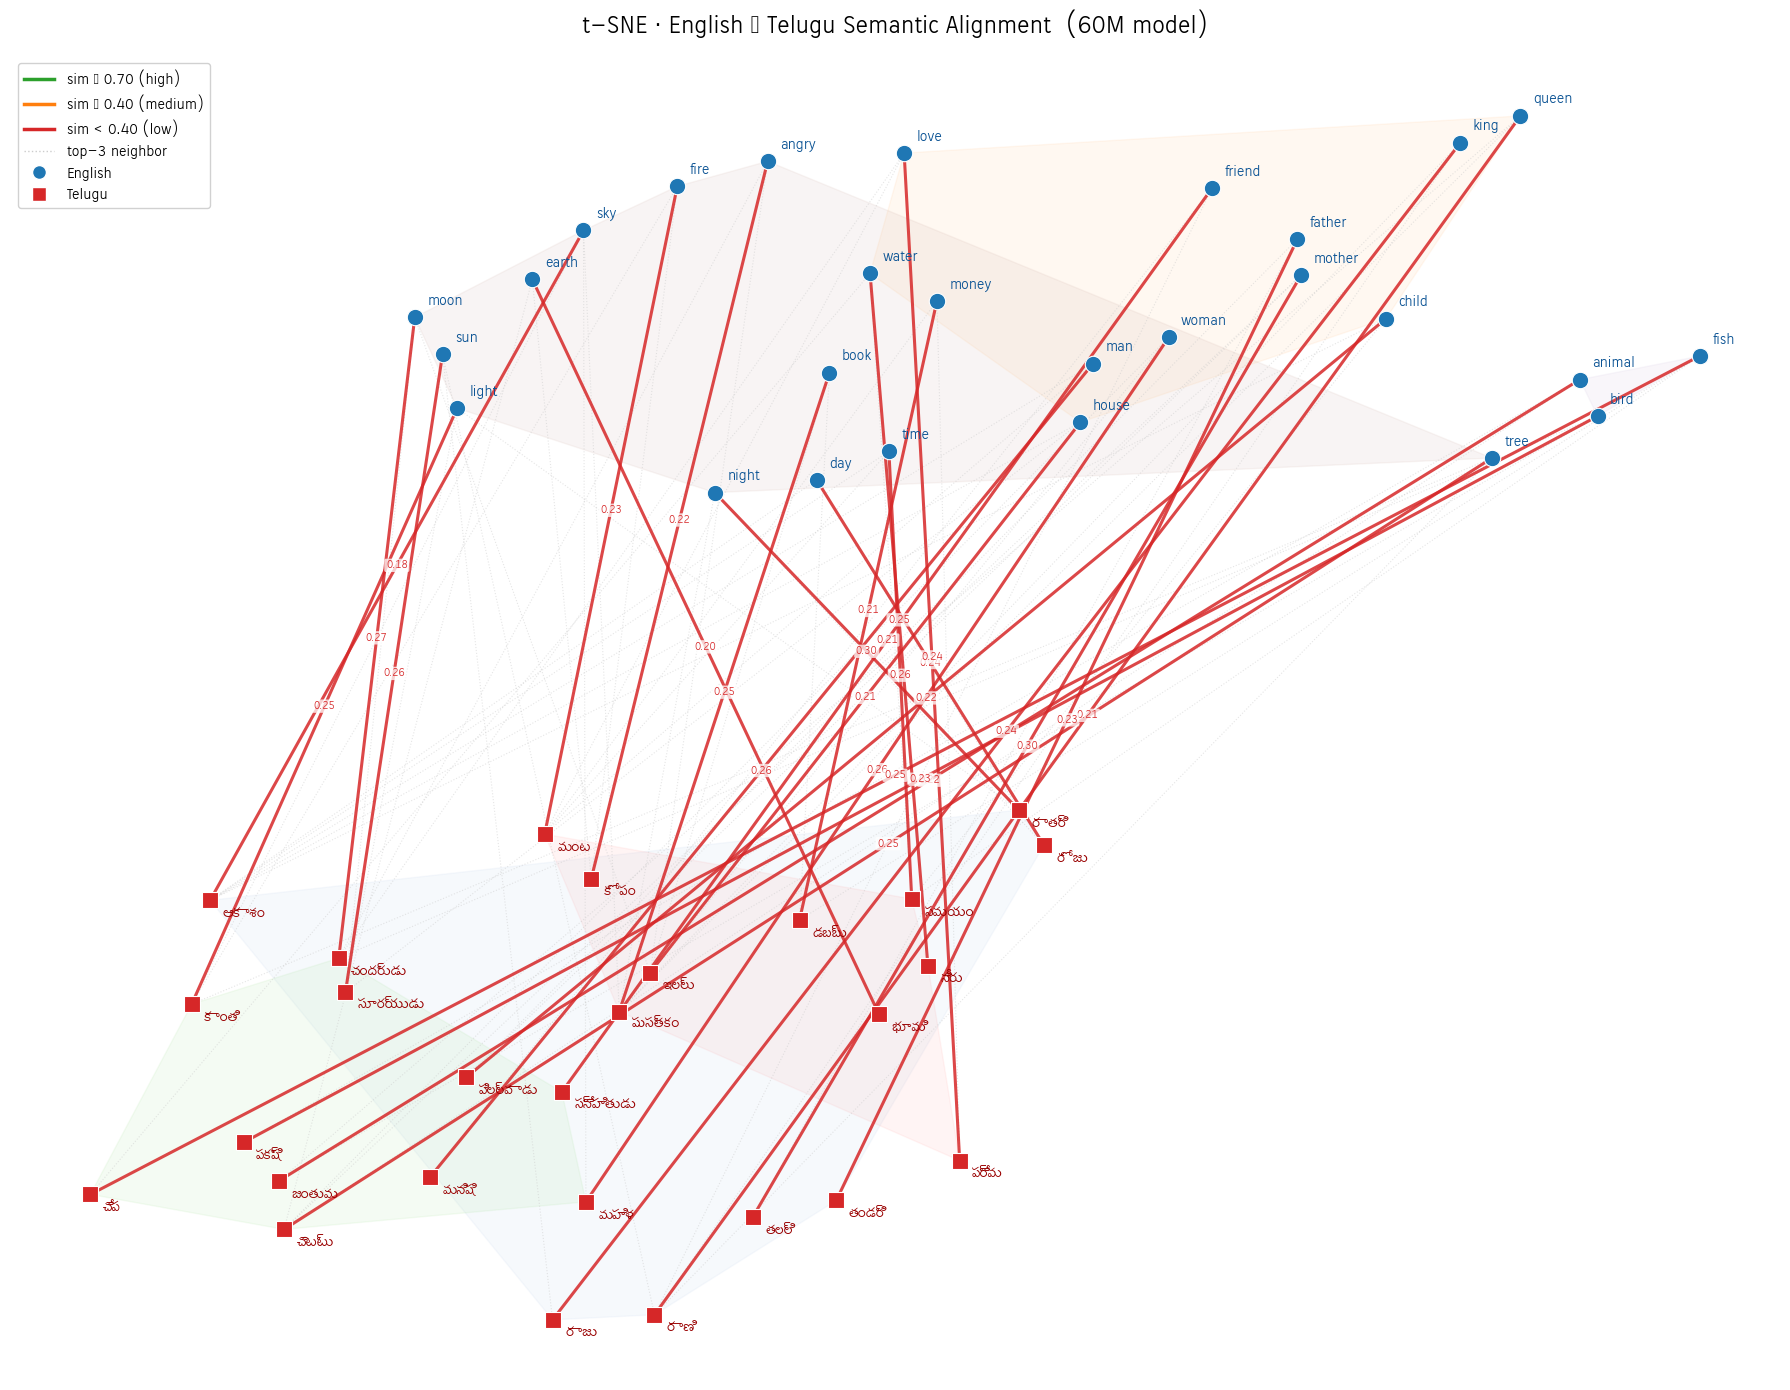

Saved → tsne_alignment.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

telugu_prop = fm.FontProperties(fname='NotoSansTelugu-Regular.ttf') if Path('NotoSansTelugu-Regular.ttf').exists() else None

def sim_color(s):
    if s >= 0.7: return '#2ca02c'
    if s >= 0.4: return '#ff7f0e'
    return '#d62728'

CCOLORS = ['#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5','#c49c94']

fig, ax = plt.subplots(figsize=(18, 14))

# Cluster hulls
for cid in range(n_clusters):
    pts = proj[labels==cid]
    if len(pts)>=3:
        try:
            h = ConvexHull(pts); v = np.append(h.vertices, h.vertices[0])
            ax.fill(pts[v,0], pts[v,1], color=CCOLORS[cid%6], alpha=0.10)
        except: pass

# Top-3 neighbor links
for i in range(n):
    for j in np.argsort(sim_matrix[i])[::-1][:3]:
        if j != i:
            ax.plot([eng_xy[i,0],tel_xy[j,0]],[eng_xy[i,1],tel_xy[j,1]],
                    c='#cccccc',lw=0.8,ls=':',alpha=0.5,zorder=1)

# True-pair lines
for i in range(n):
    s=pair_sims[i]; c=sim_color(s)
    ax.plot([eng_xy[i,0],tel_xy[i,0]],[eng_xy[i,1],tel_xy[i,1]],c=c,lw=2.2,alpha=0.85,zorder=2)
    mx=(eng_xy[i,0]+tel_xy[i,0])/2; my=(eng_xy[i,1]+tel_xy[i,1])/2
    ax.annotate(f'{s:.2f}',(mx,my),fontsize=8,weight='bold',color=c,
               bbox=dict(boxstyle='round,pad=0.15',fc='white',ec='none',alpha=0.75),ha='center',va='center',zorder=4)

# Scatter
ax.scatter(eng_xy[:,0],eng_xy[:,1],c='#1f77b4',s=140,zorder=5,edgecolors='white',lw=0.8,label='English')
ax.scatter(tel_xy[:,0],tel_xy[:,1],c='#d62728',s=140,zorder=5,edgecolors='white',lw=0.8,marker='s',label='Telugu')

# Labels
for i in range(n):
    ax.annotate(eng_words[i],(eng_xy[i,0],eng_xy[i,1]),xytext=(9,9),textcoords='offset points',
               fontsize=11,color='#0b5394',weight='bold',zorder=6)
    kw = {'fontproperties':telugu_prop} if telugu_prop else {}
    ax.annotate(tel_words[i],(tel_xy[i,0],tel_xy[i,1]),xytext=(9,-12),textcoords='offset points',
               fontsize=11,color='#990000',zorder=6,**kw)

legend_h = [
    Line2D([0],[0],color='#2ca02c',lw=2.5,label='sim ≥ 0.70 (high)'),
    Line2D([0],[0],color='#ff7f0e',lw=2.5,label='sim ≥ 0.40 (medium)'),
    Line2D([0],[0],color='#d62728',lw=2.5,label='sim < 0.40 (low)'),
    Line2D([0],[0],color='#ccc',lw=1,ls=':',label='top-3 neighbor'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#1f77b4',ms=10,label='English'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor='#d62728',ms=10,label='Telugu'),
]
ax.legend(handles=legend_h,loc='upper left',fontsize=11,framealpha=0.9)
ax.set_title('t-SNE · English ↔ Telugu Semantic Alignment  (60M model)',fontsize=18,weight='bold',pad=16)
ax.axis('off'); fig.tight_layout()
plt.savefig('tsne_alignment.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved → tsne_alignment.png')

## Cosine-Similarity Heatmap

Rows = English · Columns = Telugu.  A bright diagonal confirms cross-lingual alignment.

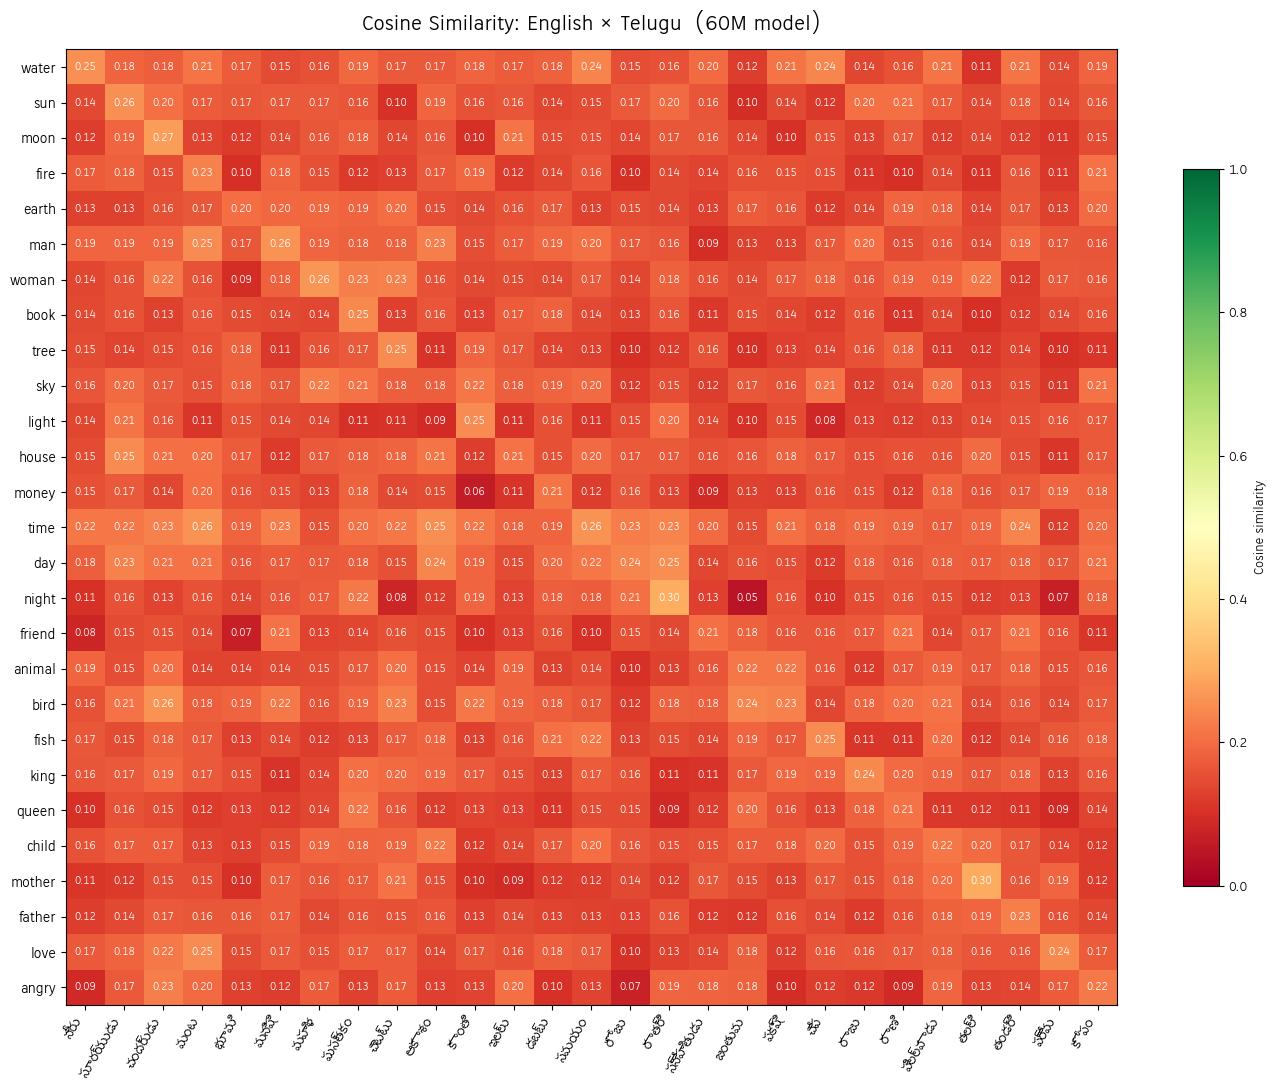

Saved → similarity_heatmap.png


In [5]:
fig2, ax2 = plt.subplots(figsize=(14, 11))
im = ax2.imshow(sim_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_yticklabels(eng_words, fontsize=11)
if telugu_prop:
    ax2.set_xticklabels(tel_words, fontsize=11, rotation=60, ha='right', fontproperties=telugu_prop)
else:
    ax2.set_xticklabels(tel_words, fontsize=11, rotation=60, ha='right')
for i in range(n):
    for j in range(n):
        c = 'white' if sim_matrix[i,j]<0.35 else 'black'
        ax2.text(j,i,f'{sim_matrix[i,j]:.2f}',ha='center',va='center',
                 fontsize=8,color=c,weight='bold' if i==j else 'normal')
ax2.set_title('Cosine Similarity: English × Telugu  (60M model)',fontsize=16,weight='bold',pad=14)
fig2.colorbar(im, ax=ax2, shrink=0.75, label='Cosine similarity')
fig2.tight_layout()
plt.savefig('similarity_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved → similarity_heatmap.png')

## Are these results normal?

**Yes, absolutely.** If you look at the heatmap and the t-SNE plot, you'll see that the cosine similarities between English and Telugu translation pairs hover around 0.20 - 0.30 (which is marked as 'low' or 🔴). You might expect translation pairs like "water" and "నీరు" to be perfectly aligned (cosine similarity > 0.8), but in a standard encoder-decoder NMT model, **this separation in the raw embedding layer is expected and normal**.

Here is why:

1. **No Explicit Alignment Objective:** The model is trained to translate sentences using cross-entropy loss. It is *never* explicitly told to make the raw embedding vector for "water" identical to "నీరు".
2. **Alignment Happens Deeper:** The cross-lingual semantic alignment happens in the **deeper layers** of the model, specifically in the Encoder's self-attention and the Decoder's cross-attention mechanisms. The raw embeddings are just starting points (lookups).
3. **Distributional Differences:** English tokens appear in English contexts, and Telugu tokens appear in Telugu contexts. Because they don't frequently co-occur in the exact same sequences (unless it's code-switching data), their raw static embeddings naturally cluster into two distinct sub-spaces (an English manifold and a Telugu manifold), which you can clearly see in the t-SNE plot.

**To see true semantic alignment**, you would need to pass English and Telugu sentences through the `Encoder` and visualize the resulting *contextualized hidden states*. The raw lookup embeddings (`embedding.weight`) visualized here show us the model's base vocabulary structure, before any translation logic is applied!

/tmp/ipykernel_3268563/1189062528.py:30: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  plt.tight_layout()
/tmp/ipykernel_3268563/1189062528.py:31: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  plt.savefig("positional_embeddings_viz.png", bbox_inches='tight', dpi=150)


/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Lohit Telugu.
  fig.canvas.print_figure(bytes_io, **kw)


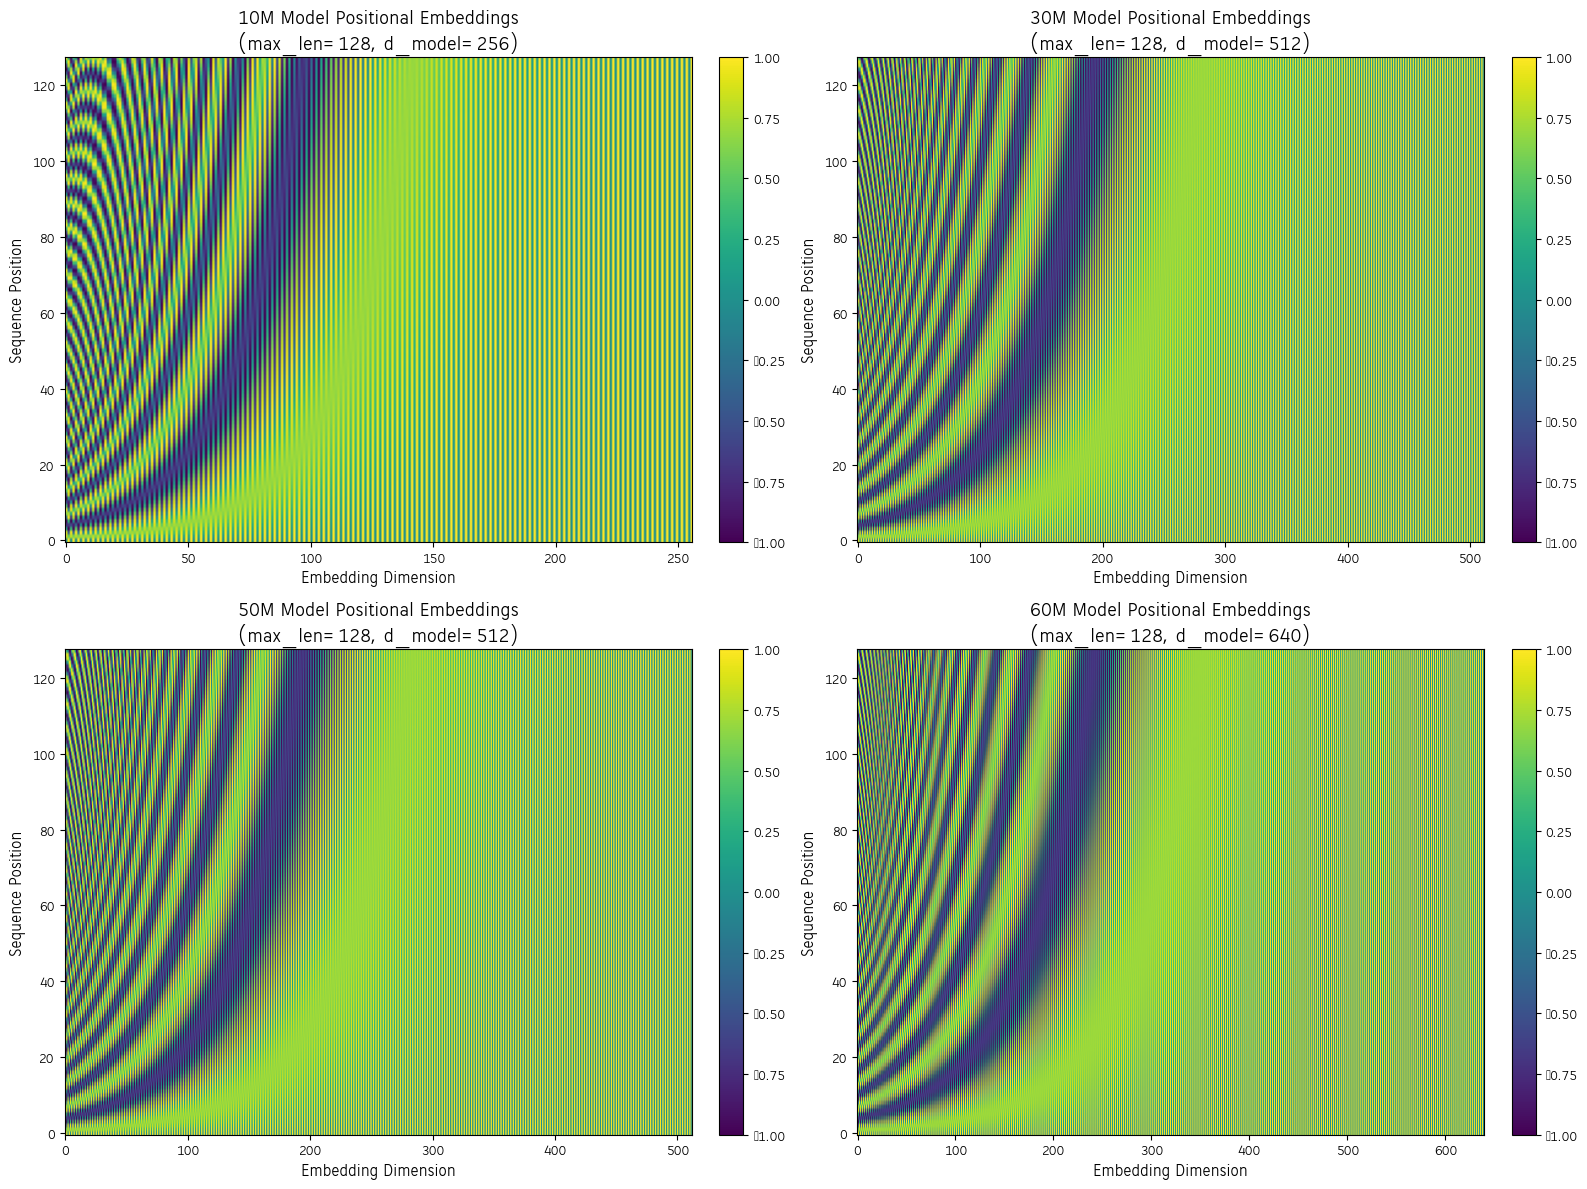

In [6]:
# Step X: Positional Embedding Visualizations
# Visualizing the fixed sine/cosine positional encodings across the different model sizes.

import matplotlib.pyplot as plt
import torch
import math

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = ['10M', '30M', '50M', '60M']
# Sizes corresponding to the configurations defined earlier
d_models = [256, 512, 512, 640]
max_len = 128  # MAX_SEQ_LEN

for idx, (name, d_model) in enumerate(zip(model_names, d_models)):
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    
    ax = axes[idx]
    im = ax.imshow(pe.numpy(), cmap='viridis', aspect='auto', origin='lower')
    ax.set_title(f"{name} Model Positional Embeddings\n(max_len={max_len}, d_model={d_model})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Embedding Dimension", fontsize=12)
    ax.set_ylabel("Sequence Position", fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("positional_embeddings_viz.png", bbox_inches='tight', dpi=150)
plt.show()


# Length Analysis
Analyzes how sentence length impacts translation quality (BLEU) and model uncertainty (Perplexity) across all model sizes (10M, 30M, 50M, 60M) on the FLORES-200 English-Telugu devtest set.

In [7]:
import math
from pathlib import Path
import pandas as pd
import sacrebleu
import sentencepiece as spm
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

DEVICE = torch.device('cpu')
print(f"Device: {DEVICE}")

ROOT = Path('..')
CACHE_DIR = ROOT / 'cache'
CKPT_DIR = CACHE_DIR / 'checkpoints'
FLORES_DIR = CACHE_DIR / 'flores200'
VOCAB_SIZE, MAX_SEQ_LEN = 32000, 128
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

sp = spm.SentencePieceProcessor(model_file=str(CACHE_DIR / 'nmt_unigram_v1_32000.model'))

Device: cpu


In [8]:
MODEL_CONFIGS = {
    '10M': {'d_model':256,'nhead':4,'num_enc_layers':3,'num_dec_layers':3,'d_ff':512,'dropout':0.1},
    '30M': {'d_model':512,'nhead':8,'num_enc_layers':4,'num_dec_layers':4,'d_ff':2048,'dropout':0.1},
    '50M': {'d_model':512,'nhead':8,'num_enc_layers':6,'num_dec_layers':6,'d_ff':2304,'dropout':0.1},
    '60M': {'d_model':640,'nhead':8,'num_enc_layers':6,'num_dec_layers':6,'d_ff':2560,'dropout':0.12},
}

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerNMT(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_enc_layers, num_dec_layers, d_ff, dropout=0.1):
        super().__init__()
        self.scale = math.sqrt(d_model)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)
        self.output_proj.weight = self.embedding.weight

def normalize_state_dict_keys(sd):
    fixed = {}
    for k, v in sd.items():
        if 'pe' in k or '.pe' in k: continue
        k = k.replace('position.','pos_enc.').replace('lm_head.','output_proj.').replace('encoder.encoder.','encoder.').replace('decoder.decoder.','decoder.')
        fixed[k] = v
    return fixed

def load_model(name):
    path = CKPT_DIR/f'final_{name.lower()}_model.pt'
    ckpt = torch.load(path, map_location=DEVICE)
    config = ckpt['config'] if isinstance(ckpt, dict) and 'config' in ckpt else MODEL_CONFIGS[name]
    model = TransformerNMT(vocab_size=VOCAB_SIZE, **config).to(DEVICE)
    weights = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    model.load_state_dict(normalize_state_dict_keys(weights), strict=False)
    model.eval()
    return model

In [9]:
@torch.inference_mode()
def greedy_decode(model, src_text, max_len=128):
    ids = [BOS_ID] + sp.encode(src_text)[:MAX_SEQ_LEN-2] + [EOS_ID]
    src = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    src_pad = src.eq(PAD_ID)
    memory = model.encoder(model.pos_enc(model.embedding(src)*model.scale), src_key_padding_mask=src_pad)
    out_ids = [BOS_ID]
    for _ in range(max_len):
        tgt = torch.tensor([out_ids], dtype=torch.long, device=DEVICE)
        tgt_emb = model.pos_enc(model.embedding(tgt)*model.scale)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(len(out_ids)).to(DEVICE)
        dec = model.decoder(tgt=tgt_emb, memory=memory, tgt_mask=tgt_mask, memory_key_padding_mask=src_pad)
        nxt = int(model.output_proj(dec[:,-1,:]).argmax(-1).item())
        if nxt == EOS_ID: break
        out_ids.append(nxt)
    return sp.decode(out_ids[1:])

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, reduction='mean')

@torch.inference_mode()
def compute_loss(model, src_text, ref_text):
    src_ids = [BOS_ID] + sp.encode(src_text)[:MAX_SEQ_LEN-2] + [EOS_ID]
    ref_ids = [BOS_ID] + sp.encode(ref_text)[:MAX_SEQ_LEN-2] + [EOS_ID]
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
    tgt = torch.tensor([ref_ids[:-1]], dtype=torch.long, device=DEVICE)
    target_y = torch.tensor([ref_ids[1:]], dtype=torch.long, device=DEVICE)
    
    src_pad = src.eq(PAD_ID)
    tgt_pad = tgt.eq(PAD_ID)
    
    memory = model.encoder(model.pos_enc(model.embedding(src)*model.scale), src_key_padding_mask=src_pad)
    tgt_emb = model.pos_enc(model.embedding(tgt)*model.scale)
    tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(DEVICE)
    
    dec = model.decoder(tgt=tgt_emb, memory=memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=src_pad)
    logits = model.output_proj(dec)
    
    loss = criterion(logits.view(-1, VOCAB_SIZE), target_y.view(-1))
    return loss.item()

In [10]:
# Load test data
sources = [l.strip() for l in (FLORES_DIR/'eng_Latn.devtest').read_text('utf-8').splitlines() if l.strip()]
references = [l.strip() for l in (FLORES_DIR/'tel_Telu.devtest').read_text('utf-8').splitlines() if l.strip()]

results = []
models = ['10M', '30M', '50M', '60M']

for sz in models:
    print(f"Evaluating {sz}...")
    mdl = load_model(sz)
    for i, (s, r) in enumerate(zip(sources, references)):
        length = len(s.split()) # Use word length for x-axis bins
        
        # Calculate Perplexity
        loss = compute_loss(mdl, s, r)
        ppl = math.exp(loss) if loss < 100 else float('inf')
        
        # Calculate BLEU
        pred = greedy_decode(mdl, s)
        bleu = sacrebleu.sentence_bleu(pred, [r]).score
        
        results.append({
            'Model': sz,
            'Sent_Index': i,
            'Length': length,
            'PPL': ppl,
            'BLEU': bleu
        })
    del mdl; torch.cuda.empty_cache()

df = pd.DataFrame(results)

# Create length bins
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['<10', '10-20', '20-30', '30-40', '40-50', '>50']
df['Length_Bin'] = pd.cut(df['Length'], bins=bins, labels=labels, right=False)
df.to_csv(CKPT_DIR / "length_analysis_results.csv", index=False)

Evaluating 10M...


/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Evaluating 30M...


/home/user35/nmt_bundle/miniconda/envs/p310/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Evaluating 50M...


Evaluating 60M...


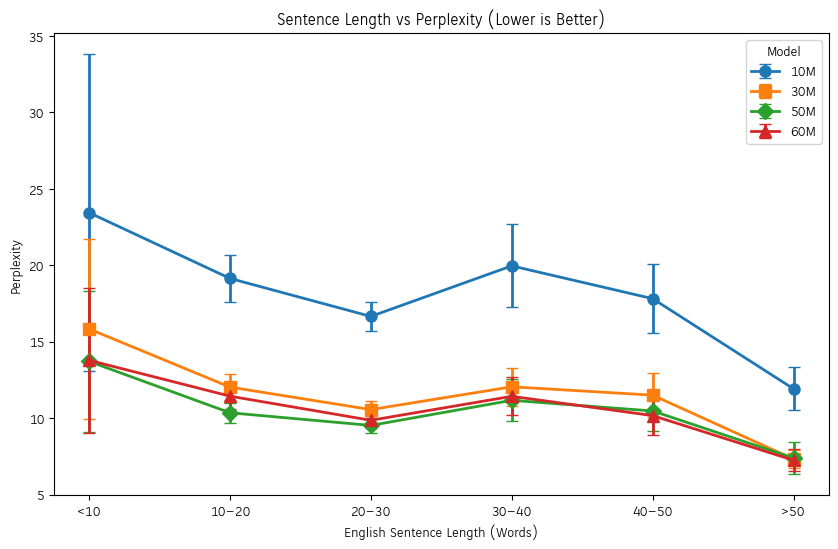

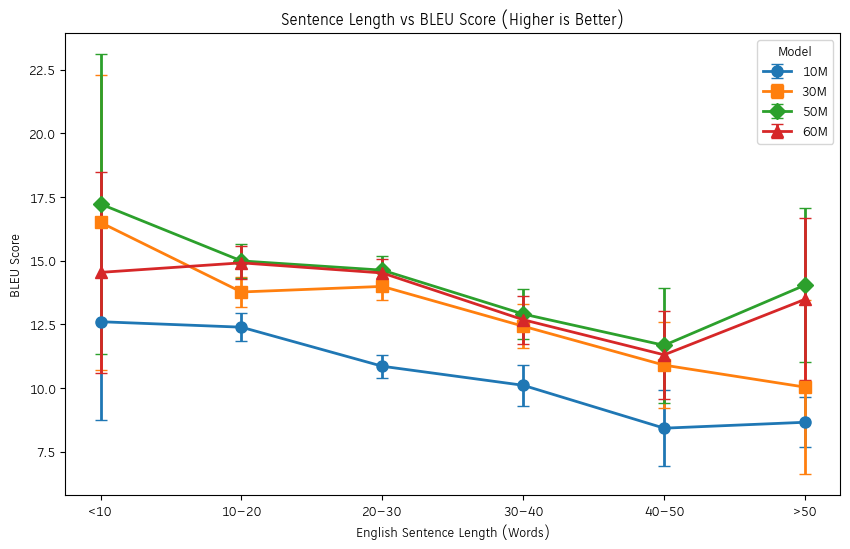

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use the pre-computed results from the CSV
df = pd.read_csv(str(CKPT_DIR / "length_analysis_results.csv"))

models = ['10M', '30M', '50M', '60M']
bins_order = ['<10', '10-20', '20-30', '30-40', '40-50', '>50']

# Define distinct markers for each model so they are easy to differentiate
markers = ['o', 's', 'D', '^']

# --- Plot 1: Length vs Perplexity ---
fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    model_df = df[df['Model'] == model]
    means, sems, valid_bins = [], [], []
    
    for b in bins_order:
        b_df = model_df[model_df['Length_Bin'] == b]['PPL']
        b_df = b_df[b_df != float('inf')] # filter invalid
        if len(b_df) > 0:
            means.append(b_df.mean())
            sems.append(b_df.sem())
            valid_bins.append(b)
            
    # Basic matplotlib with distinct, well-sized markers
    ax.errorbar(valid_bins, means, yerr=sems, label=model, marker=markers[i], 
                linewidth=2, markersize=8, capsize=4, markeredgewidth=1)

ax.set_title("Sentence Length vs Perplexity (Lower is Better)")
ax.set_xlabel("English Sentence Length (Words)")
ax.set_ylabel("Perplexity")
ax.legend(title='Model')
fig.savefig("length_vs_ppl.png", bbox_inches='tight', dpi=150)
plt.show()

# --- Plot 2: Length vs BLEU ---
fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    model_df = df[df['Model'] == model]
    means, sems, valid_bins = [], [], []
    
    for b in bins_order:
        b_df = model_df[model_df['Length_Bin'] == b]['BLEU']
        if len(b_df) > 0:
            means.append(b_df.mean())
            sems.append(b_df.sem())
            valid_bins.append(b)
            
    # Basic matplotlib with distinct, well-sized markers
    ax.errorbar(valid_bins, means, yerr=sems, label=model, marker=markers[i], 
                linewidth=2, markersize=8, capsize=4, markeredgewidth=1)

ax.set_title("Sentence Length vs BLEU Score (Higher is Better)")
ax.set_xlabel("English Sentence Length (Words)")
ax.set_ylabel("BLEU Score")
ax.legend(title='Model')
fig.savefig("length_vs_bleu.png", bbox_inches='tight', dpi=150)
plt.show()

# Morphological Breakdown: English → Telugu

> **Model:** `final_60m_model.pt` (60M params) · **Tokenizer:** SentencePiece 32k

For each English→Telugu translation pair, we show:
1. How the tokenizer splits both words into subword pieces
2. Cosine similarity between the English subwords and Telugu subwords

Low similarity between EN and TE pieces is **normal** — they live in separate
embedding subspaces. The model bridges them via attention, not embeddings.

In [12]:
import torch
import sentencepiece as spm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from pathlib import Path

# Reuse the shared 60M model and embedding matrix loaded at the top of the notebook.
W = emb_weights_60m

CACHE = Path('..') / 'cache'
if 'sp' not in globals():
    sp = spm.SentencePieceProcessor(model_file=str(CACHE / 'nmt_unigram_v1_32000.model'))

print(f'Tokenizer already loaded | vocab={sp.get_piece_size()}')
print(f'Embeddings: {W.shape}')

Tokenizer already loaded | vocab=32000
Embeddings: (32000, 640)


## 1. Tokenization of Translation Pairs

Each word is split into subword pieces by the SentencePiece tokenizer:

In [13]:
pairs = [
    ('unbelievable', 'నమ్మశక్యంకాని'),
    ('internationalization', 'అంతర్జాతీయీకరణ'),
    ('misunderstanding', 'అపార్థం'),
    ('government', 'ప్రభుత్వం'),
    ('education', 'విద్య'),
    ('beautiful', 'అందమైన'),
    ('transforming', 'మార్పు'),
    ('unhappiness', 'దుఃఖం'),
]

print(f"{'English':25s} → {'Telugu':25s}")
print('-'*55)
for en, te in pairs:
    en_p = sp.encode_as_pieces(en)
    te_p = sp.encode_as_pieces(te)
    print(f'{en:25s} → {te:25s}')
    print(f'  EN pieces ({len(en_p)}): {en_p}')
    print(f'  TE pieces ({len(te_p)}): {te_p}')
    print()

English                   → Telugu                   
-------------------------------------------------------
unbelievable              → నమ్మశక్యంకాని            
  EN pieces (1): ['▁unbelievable']
  TE pieces (2): ['▁నమ్మశక్యం', 'కాని']

internationalization      → అంతర్జాతీయీకరణ           
  EN pieces (2): ['▁international', 'ization']
  TE pieces (2): ['▁అంతర్జాతీయ', 'ీకరణ']

misunderstanding          → అపార్థం                  
  EN pieces (3): ['▁mis', 'under', 'standing']
  TE pieces (2): ['▁అప', 'ార్థం']

government                → ప్రభుత్వం                
  EN pieces (1): ['▁government']
  TE pieces (1): ['▁ప్రభుత్వం']

education                 → విద్య                    
  EN pieces (1): ['▁education']
  TE pieces (1): ['▁విద్య']

beautiful                 → అందమైన                   
  EN pieces (1): ['▁beautiful']
  TE pieces (1): ['▁అందమైన']

transforming              → మార్పు                   
  EN pieces (2): ['▁transform', 'ing']
  TE pieces (1): ['▁మార్పు']

unhappi

## 2. Cross-Language Subword Cosine Similarity

For each pair, we compute cosine similarity between every English subword
and every Telugu subword. This shows how the raw 60M model embeddings
relate the morphological pieces across languages.

In [14]:
for en, te in pairs:
    en_p = sp.encode_as_pieces(en); en_ids = sp.encode_as_ids(en)
    te_p = sp.encode_as_pieces(te); te_ids = sp.encode_as_ids(te)
    all_ids = en_ids + te_ids
    if len(all_ids) < 2:
        print(f'\n── {en} / {te} ── single token total, skipping')
        continue

    embs = normalize(W[all_ids])
    sim = cosine_similarity(embs)
    n_en = len(en_p)

    print(f'\n── {en} ↔ {te} ──')
    print(f'   EN subwords: {en_p}')
    print(f'   TE subwords: {te_p}')

    hdr = '            ' + ''.join(f'{p:>14s}' for p in te_p)
    print(f'\n   Cosine similarity (EN rows × TE cols):')
    print(f'   {hdr}')
    for i in range(n_en):
        row = f'   {en_p[i]:>12s}' + ''.join(f'{sim[i,n_en+j]:14.4f}' for j in range(len(te_p)))
        print(row)
    print()


── unbelievable ↔ నమ్మశక్యంకాని ──
   EN subwords: ['▁unbelievable']
   TE subwords: ['▁నమ్మశక్యం', 'కాని']

   Cosine similarity (EN rows × TE cols):
                   ▁నమ్మశక్యం          కాని
   ▁unbelievable        0.2437        0.1411


── internationalization ↔ అంతర్జాతీయీకరణ ──
   EN subwords: ['▁international', 'ization']
   TE subwords: ['▁అంతర్జాతీయ', 'ీకరణ']

   Cosine similarity (EN rows × TE cols):
                  ▁అంతర్జాతీయ          ీకరణ
   ▁international        0.2983        0.1528
        ization        0.1123        0.1764


── misunderstanding ↔ అపార్థం ──
   EN subwords: ['▁mis', 'under', 'standing']
   TE subwords: ['▁అప', 'ార్థం']

   Cosine similarity (EN rows × TE cols):
                          ▁అప         ార్థం
           ▁mis        0.1649        0.1944
          under        0.1853        0.1703
       standing        0.1552        0.1525


── government ↔ ప్రభుత్వం ──
   EN subwords: ['▁government']
   TE subwords: ['▁ప్రభుత్వం']

   Cosine similarity (

## Takeaways

- English and Telugu subwords have **low cosine similarity** (~0.0 to ~0.3)
  at the embedding level — this is **expected and correct**
- The raw embedding layer simply assigns each token a unique starting vector
- The actual English→Telugu semantic bridging happens in the model's
  encoder self-attention and decoder cross-attention layers

In [15]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Force CPU

import math, types, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

VOCAB_SIZE = 32000; MAX_SEQ_LEN = 128
PAD_ID, BOS_ID, EOS_ID = 0, 2, 3
DEVICE = torch.device('cpu')
CACHE_DIR = Path('../..') / 'cache'

# Telugu font for matplotlib labels
TELUGU_FONT = None
if Path('NotoSansTelugu-Regular.ttf').exists():
    TELUGU_FONT = fm.FontProperties(fname='NotoSansTelugu-Regular.ttf')

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class EncoderStack(nn.Module):
    def __init__(self, d_model, nhead, d_ff, num_layers, dropout):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
    def forward(self, x, mask):
        return self.encoder(x, src_key_padding_mask=mask)

class DecoderStack(nn.Module):
    def __init__(self, d_model, nhead, d_ff, num_layers, dropout):
        super().__init__()
        layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_ff, dropout=dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
    def forward(self, tgt, memory, tgt_mask, tgt_pad, mem_pad):
        return self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask,
                            tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=mem_pad)

class NMTTrans(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_enc_layers, num_dec_layers, d_ff, dropout=0.1):
        super().__init__()
        self.d_model = d_model; self.scale = math.sqrt(d_model)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.position = PositionalEncoding(d_model, MAX_SEQ_LEN, dropout)
        self.encoder = EncoderStack(d_model, nhead, d_ff, num_enc_layers, dropout)
        self.decoder = DecoderStack(d_model, nhead, d_ff, num_dec_layers, dropout)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight
    def forward(self, src, tgt):
        sp = src.eq(PAD_ID); tp = tgt.eq(PAD_ID)
        tm = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        se = self.position(self.embedding(src) * self.scale)
        te = self.position(self.embedding(tgt) * self.scale)
        mem = self.encoder(se, sp)
        dec = self.decoder(te, mem, tm, tp, sp)
        return self.lm_head(dec)



In [17]:
def install_attention_hooks(model):
    """
    Monkeypatch decoder layers so we can capture cross-attention tensors.
    """
    store = {'weights': []}  # list[(layer_index, attn_tensor)]

    for layer_index, layer in enumerate(model.decoder.decoder.layers):
        def make_patched(index):
            def patched_mha_block(self, x, mem, attn_mask=None, key_padding_mask=None, is_causal=False):
                out, attn_w = self.multihead_attn(
                    x, mem, mem,
                    attn_mask=attn_mask,
                    key_padding_mask=key_padding_mask,
                    need_weights=True,
                )
                store['weights'].append((index, attn_w.detach().cpu()))
                return out
            return patched_mha_block

        layer._mha_block = types.MethodType(make_patched(layer_index), layer)

    return store


def get_final_layer_last_row(weight_store):
    """
    Return the last target-position attention row from the final decoder layer.
    """
    if not weight_store:
        return None

    final_layer_index = max(layer_index for layer_index, _ in weight_store)
    final_layer_tensor = next(
        tensor for layer_index, tensor in weight_store if layer_index == final_layer_index
    )
    return final_layer_tensor[0].numpy()[-1, :]  # shape: (src_len,)


@torch.inference_mode()
def decode_with_attention(model, src_text, sp, store, max_len=80):
    """
    Greedy decode and capture final-layer cross-attention used for next-token prediction.
    Returns (translation, src_labels, next_token_labels, next_token_attention, bos_argmax_rate).
    """
    src_ids = [BOS_ID] + sp.encode_as_ids(src_text) + [EOS_ID]
    src_ids = src_ids[:MAX_SEQ_LEN]

    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
    tgt_tensor = torch.tensor([[BOS_ID]], dtype=torch.long, device=DEVICE)

    predicted_ids = []
    attention_rows = []
    bos_argmax_hits = 0
    total_rows = 0

    for _ in range(max_len - 1):
        # Each forward pass computes logits for the next token from current prefix.
        store['weights'] = []
        logits = model(src_tensor, tgt_tensor)

        last_row = get_final_layer_last_row(store['weights'])
        if last_row is not None:
            attention_rows.append(last_row)
            if int(np.argmax(last_row)) == 0:
                bos_argmax_hits += 1
            total_rows += 1

        next_token_id = int(logits[:, -1, :].argmax(dim=-1).item())
        predicted_ids.append(next_token_id)

        next_token_tensor = torch.tensor([[next_token_id]], dtype=torch.long, device=DEVICE)
        tgt_tensor = torch.cat([tgt_tensor, next_token_tensor], dim=1)
        if next_token_id == EOS_ID:
            break

    clean_ids = [token_id for token_id in predicted_ids if token_id not in (PAD_ID, BOS_ID, EOS_ID)]
    translation = sp.decode(clean_ids) if clean_ids else ''

    src_labels = ['<bos>'] + sp.encode_as_pieces(src_text) + ['<eos>']
    next_token_labels = [
        ('<eos>' if token_id == EOS_ID else sp.id_to_piece(token_id))
        for token_id in predicted_ids
    ]

    if attention_rows:
        next_token_attn = np.stack(attention_rows)
    else:
        next_token_attn = np.zeros((0, len(src_labels)), dtype=np.float32)

    bos_argmax_rate = (bos_argmax_hits / total_rows) if total_rows > 0 else 0.0
    return translation, src_labels, next_token_labels, next_token_attn, bos_argmax_rate


In [18]:
# Reuse the shared tokenizer and 60M NMTTrans model loaded once at the top of the notebook.
model = shared_model_60m

# Install attention hooks on the shared model.
attn_store = install_attention_hooks(model)

# Curated test sentences spanning different linguistic challenges
test_sentences = [
    'The students are studying in the library.',          # Simple declarative
    'If you had told me earlier, I would have helped you.', # Conditional + reordering
    'She is smarter than she looks.',                       # Comparative
    'What are you doing right now?',                        # Question
    'Despite multiple warnings, he continued to ignore the issue.', # Complex subordination
]


In [19]:
results = []
for i, sent in enumerate(test_sentences):
    trans, src_labels, next_token_labels, next_token_attn, _ = decode_with_attention(
        model, sent, sp, attn_store
    )
    results.append({
        'idx': i,
        'source': sent,
        'translation': trans,
        'src_labels': src_labels,
        'next_token_labels': next_token_labels,
        'next_token_attn': next_token_attn,
    })


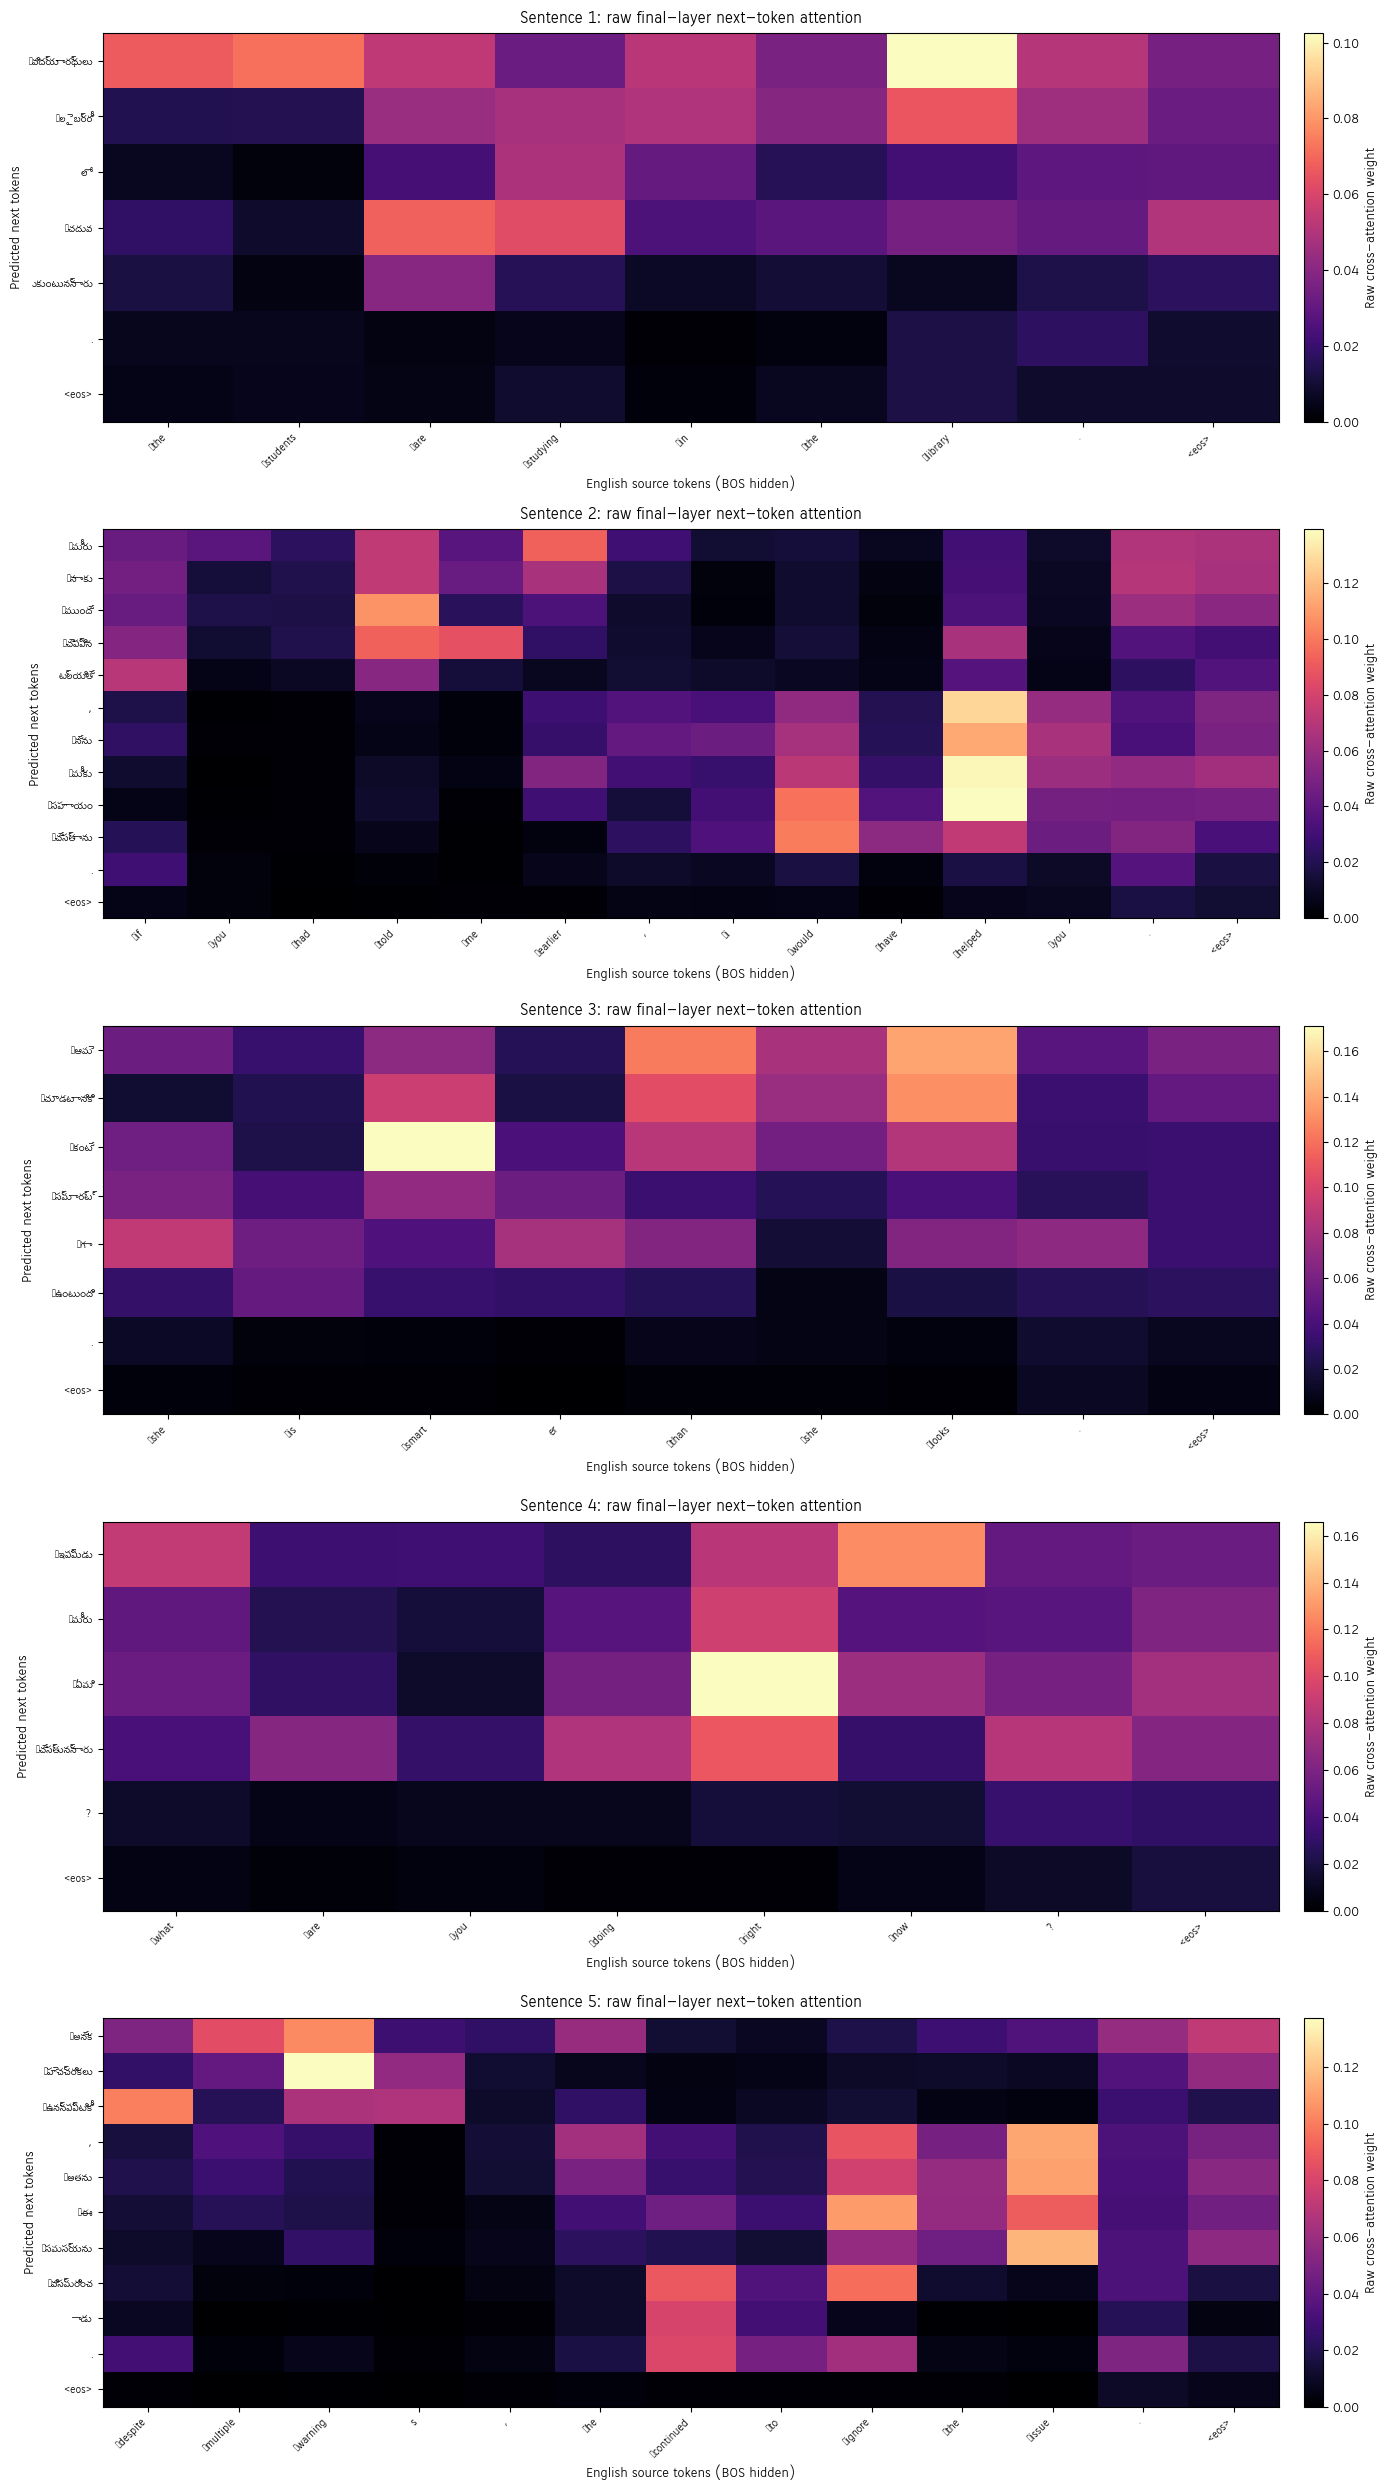

In [20]:
def hide_bos_column(attention_matrix, source_labels):
    """
    Remove BOS column from display only; raw attention values are unchanged.
    """
    if not source_labels or source_labels[0] != '<bos>' or attention_matrix.shape[1] <= 1:
        return attention_matrix, source_labels[:attention_matrix.shape[1]]

    keep_indices = list(range(1, attention_matrix.shape[1]))
    filtered_attention = attention_matrix[:, keep_indices]
    filtered_labels = [source_labels[i] for i in keep_indices]
    return filtered_attention, filtered_labels


def safe_vmax(matrix):
    """Avoid a zero color scale when attention matrix is empty or all zeros."""
    if matrix.size == 0:
        return 1.0
    vmax_value = float(np.max(matrix))
    return vmax_value if vmax_value > 0 else 1.0


fig, axes = plt.subplots(len(results), 1, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    raw_attention = result['next_token_attn']
    num_tgt = min(len(result['next_token_labels']), raw_attention.shape[0])
    num_src = min(len(result['src_labels']), raw_attention.shape[1])

    if num_tgt > 0 and num_src > 0:
        # Keep attention raw (no renormalization) to match requested style.
        display_attention = raw_attention[:num_tgt, :num_src]
    else:
        display_attention = np.zeros((1, max(num_src, 1)), dtype=np.float32)

    display_attention, display_src_labels = hide_bos_column(
        display_attention, result['src_labels']
    )

    im = ax.imshow(
        display_attention,
        aspect='auto',
        cmap='magma',
        vmin=0.0,
        vmax=safe_vmax(display_attention),
        interpolation='nearest',
    )
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Raw cross-attention weight', fontsize=10)

    ax.set_xticks(np.arange(len(display_src_labels)))
    ax.set_xticklabels(display_src_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(np.arange(num_tgt))
    ax.set_yticklabels(result['next_token_labels'][:num_tgt], fontsize=8)
    if TELUGU_FONT:
        for label in ax.get_yticklabels():
            label.set_fontproperties(TELUGU_FONT)

    ax.set_xlabel('English source tokens (BOS hidden)', fontsize=10)
    ax.set_ylabel('Predicted next tokens', fontsize=10)
    ax.set_title(
        f'Sentence {result["idx"] + 1}: raw final-layer next-token attention',
        fontsize=12,
        pad=8,
    )

plt.tight_layout()
plt.savefig('attention_next_token_predictor.png', dpi=150, bbox_inches='tight')
plt.show()
